# Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## Step 1: Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

### Explanation

The required Python libraries are imported for data manipulation, visualization, preprocessing, clustering, and evaluation of the machine learning model.

## Step 2: Load the Cleaned Dataset

In [16]:
df = pd.read_excel("../Dataset/merged_data.xlsx")

In [17]:
import pandas as pd

df = pd.read_excel("../Dataset/merged_data.xlsx")

In [18]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,90343,9,2024-01-10,Apartment,40,1090.32,351419.29,Sold,C0001
1,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,4051,4,2024-01-12,Apartment,51,1608.84,496266.41,Sold,C0001
2,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,150099,15,2025-01-05,Apartment,15,522.71,175599.90,Sold,C0001
3,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,30432,3,2025-01-12,Apartment,50,713.67,223479.12,Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,2024-01-01,Apartment,6,938.57,299245.20,Sold,C0002


In [19]:
print(df.columns.tolist())

['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


## Step 3: Feature Engineering

The `date_of_birth` column is converted into a new `Age` feature because machine learning algorithms require numeric values. Age is a more meaningful feature for customer segmentation than the raw birth date.

In [21]:
from datetime import datetime

# Convert to datetime
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"])

# Calculate Age
current_year = datetime.now().year
df["age"] = current_year - df["date_of_birth"].dt.year

# Preview
df[["date_of_birth", "age"]].head()

,date_of_birth,age
0,1968-11-05,58
1,1968-11-05,58
2,1968-11-05,58
3,1968-11-05,58
4,1962-11-26,64


## Step 4: Feature Selection

Only relevant customer and transaction features are selected for clustering. Identifier columns and names are excluded because they do not contribute to meaningful customer segmentation.

In [23]:
ml_df = df[
    [
        "client_type",
        "gender",
        "country",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel",
        "unit_category",
        "listing_status",
        "satisfaction_score",
        "floor_area_sqft",
        "sale_price",
        "age",
    ]
]

ml_df.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,unit_category,listing_status,satisfaction_score,floor_area_sqft,sale_price,age
0,Individual,F,USA,California,Home,Yes,Website,Apartment,Sold,4,1090.32,351419.29,58
1,Individual,F,USA,California,Home,Yes,Website,Apartment,Sold,4,1608.84,496266.41,58
2,Individual,F,USA,California,Home,Yes,Website,Apartment,Sold,4,522.71,175599.90,58
3,Individual,F,USA,California,Home,Yes,Website,Apartment,Sold,4,713.67,223479.12,58
4,Individual,M,USA,California,Home,No,Website,Apartment,Sold,1,938.57,299245.20,64


In [24]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_type          7305 non-null   object 
 1   gender               7305 non-null   object 
 2   country              7305 non-null   object 
 3   region               7305 non-null   object 
 4   acquisition_purpose  7305 non-null   object 
 5   loan_applied         7305 non-null   object 
 6   referral_channel     7305 non-null   object 
 7   unit_category        7305 non-null   object 
 8   listing_status       7305 non-null   object 
 9   satisfaction_score   7305 non-null   int64  
 10  floor_area_sqft      7305 non-null   float64
 11  sale_price           7305 non-null   float64
 12  age                  7305 non-null   int32  
dtypes: float64(2), int32(1), int64(1), object(9)
memory usage: 713.5+ KB


## Step 5: Feature Encoding

Categorical variables are converted into numerical format using One-Hot Encoding. This allows machine learning algorithms such as K-Means to process categorical information without introducing an artificial order between categories.

In [25]:
# One-Hot Encoding
ml_encoded = pd.get_dummies(
    ml_df,
    columns=[
        "client_type",
        "gender",
        "country",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel",
        "unit_category",
        "listing_status"
    ],
    drop_first=True
)

In [26]:
ml_encoded.head()

,satisfaction_score,floor_area_sqft,sale_price,age,client_type_Individual,gender_M,country_Belgium,country_Canada,country_Denmark,country_France,...,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Investment,loan_applied_Yes,referral_channel_Client,referral_channel_Website,unit_category_Office
0,4,1090.32,351419.29,58,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,4,1608.84,496266.41,58,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,4,522.71,175599.90,58,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,4,713.67,223479.12,58,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
4,1,938.57,299245.20,64,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [28]:
ml_encoded.shape

(7305, 76)

In [29]:
ml_encoded.to_excel("../Dataset/encoded_data.xlsx", index=False)

## Step 6: Feature Scaling

Machine learning algorithms such as K-Means are distance-based. Therefore, all numerical features are standardized using StandardScaler so that each feature contributes equally to the clustering process.

In [30]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale the entire encoded dataset
scaled_data = scaler.fit_transform(ml_encoded)

In [31]:
scaled_data.shape

(7305, 76)

In [32]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=ml_encoded.columns
)

In [33]:
scaled_df.head()

,satisfaction_score,floor_area_sqft,sale_price,age,client_type_Individual,gender_M,country_Belgium,country_Canada,country_Denmark,country_France,...,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Investment,loan_applied_Yes,referral_channel_Client,referral_channel_Website,unit_category_Office
0,0.669683,-0.121246,0.048069,0.091061,0.234576,-1.019492,-0.150597,-0.206946,-0.084673,-0.162085,...,-0.086297,-0.185892,-0.052396,-0.026171,-0.03097,-0.666518,1.31213,-0.324774,0.893271,-0.416526
1,0.669683,1.115643,1.145024,0.091061,0.234576,-1.019492,-0.150597,-0.206946,-0.084673,-0.162085,...,-0.086297,-0.185892,-0.052396,-0.026171,-0.03097,-0.666518,1.31213,-0.324774,0.893271,-0.416526
2,0.669683,-1.475236,-1.283445,0.091061,0.234576,-1.019492,-0.150597,-0.206946,-0.084673,-0.162085,...,-0.086297,-0.185892,-0.052396,-0.026171,-0.03097,-0.666518,1.31213,-0.324774,0.893271,-0.416526
3,0.669683,-1.019715,-0.920846,0.091061,0.234576,-1.019492,-0.150597,-0.206946,-0.084673,-0.162085,...,-0.086297,-0.185892,-0.052396,-0.026171,-0.03097,-0.666518,1.31213,-0.324774,0.893271,-0.416526
4,-1.448997,-0.483234,-0.347055,0.439058,0.234576,0.980881,-0.150597,-0.206946,-0.084673,-0.162085,...,-0.086297,-0.185892,-0.052396,-0.026171,-0.03097,-0.666518,-0.76212,-0.324774,0.893271,-0.416526


In [34]:
scaled_df.to_excel("../Dataset/scaled_data.xlsx", index=False)

## Step 7: Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. The Within-Cluster Sum of Squares (WCSS) is calculated for different values of K, and the point where the reduction in WCSS begins to level off is selected as the optimal number of clusters.

In [35]:
from sklearn.cluster import KMeans

In [36]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

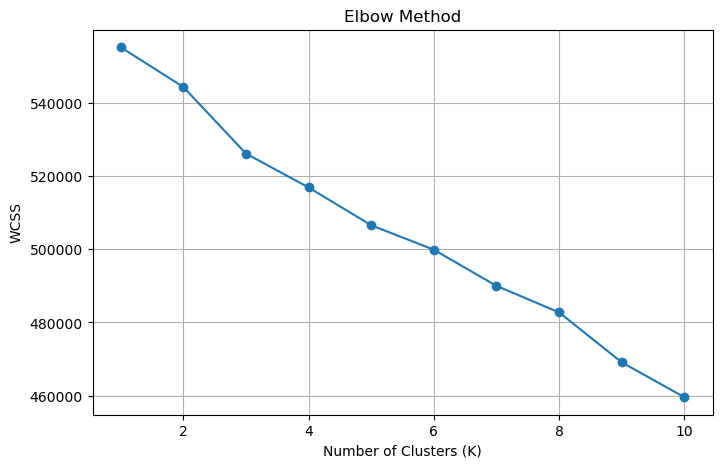

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()

### Interpretation

The Elbow Method was used to determine the optimal number of clusters. The graph shows a noticeable change in the rate of decrease in WCSS around **K = 3**. Therefore, **three clusters** were selected for K-Means clustering because increasing the number of clusters beyond this point provides only marginal improvements in reducing WCSS.

## Step 8: K-Means Clustering

After identifying the optimal number of clusters using the Elbow Method, the K-Means algorithm is trained with **3 clusters**. Each customer is assigned to one of the clusters based on similarities in demographic, financial, and transaction characteristics.

In [38]:
# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit the model
kmeans.fit(scaled_df)

# Assign cluster labels
df["Cluster"] = kmeans.labels_

In [39]:
df[["client_id", "Cluster"]].head()

,client_id,Cluster
0,C0001,2
1,C0001,2
2,C0001,2
3,C0001,2
4,C0002,2


In [40]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1562
1      73
2    5670
Name: count, dtype: int64

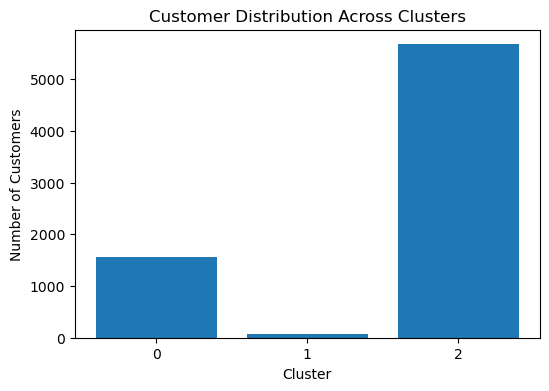

In [41]:
import matplotlib.pyplot as plt

cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [42]:
df.to_excel("../Dataset/final_clustered_data.xlsx", index=False)

In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df, kmeans.labels_)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.302


In [45]:
cluster_profile = df.groupby("Cluster").agg({
    "sale_price": "mean",
    "floor_area_sqft": "mean",
    "age": "mean",
    "satisfaction_score": "mean"
})

cluster_profile

,sale_price,floor_area_sqft,age,satisfaction_score
Cluster,,,,
0,344782.076460,1142.279526,54.854673,3.039693
1,348821.258082,1148.922740,54.739726,3.123288
2,345103.598866,1140.735975,56.885714,3.054145


In [46]:
pd.crosstab(df["Cluster"], df["client_type"])

client_type,Company,Individual
Cluster,,
0,78,1484
1,0,73
2,303,5367


In [48]:
pd.crosstab(df["Cluster"], df["acquisition_purpose"])

acquisition_purpose,Home,Investment
Cluster,,
0,1045,517
1,63,10
2,3950,1720


In [49]:
pd.crosstab(df["Cluster"], df["country"])

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,119,162,227,52,187,195,144,128,348,0
1,0,0,73,0,0,0,0,0,0,0
2,14,0,0,0,0,0,0,0,0,5656


In [50]:
pd.crosstab(df["Cluster"], df["loan_applied"])

loan_applied,No,Yes
Cluster,,
0,966,596
1,52,21
2,3603,2067


# Step 09: Cluster Interpretation
| Cluster       | Customers | Characteristics                                                                 | Suggested Name                      |
| ------------- | --------: | ------------------------------------------------------------------------------- | ----------------------------------- |
| **Cluster 0** |     1,562 | Mostly individual buyers, mixed countries, balanced home & investment purchases | **International Individual Buyers** |
| **Cluster 1** |        73 | Smallest group, all individuals, all from Canada, mostly home purchases         | **Canadian Home Buyers**            |
| **Cluster 2** |     5,670 | Largest group, mostly USA, mostly individuals, home purchases dominate          | **Domestic Residential Buyers**     |


# Step 10: Hierarchical Clustering

Hierarchical Clustering is performed to validate the K-Means clustering results. A dendrogram is generated to visualize how customer records are grouped based on their similarity.

In [52]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [53]:
sample_data = scaled_df.sample(n=500, random_state=42)

In [57]:
linkage_matrix = linkage(
    sample_data,
    method="ward"
)

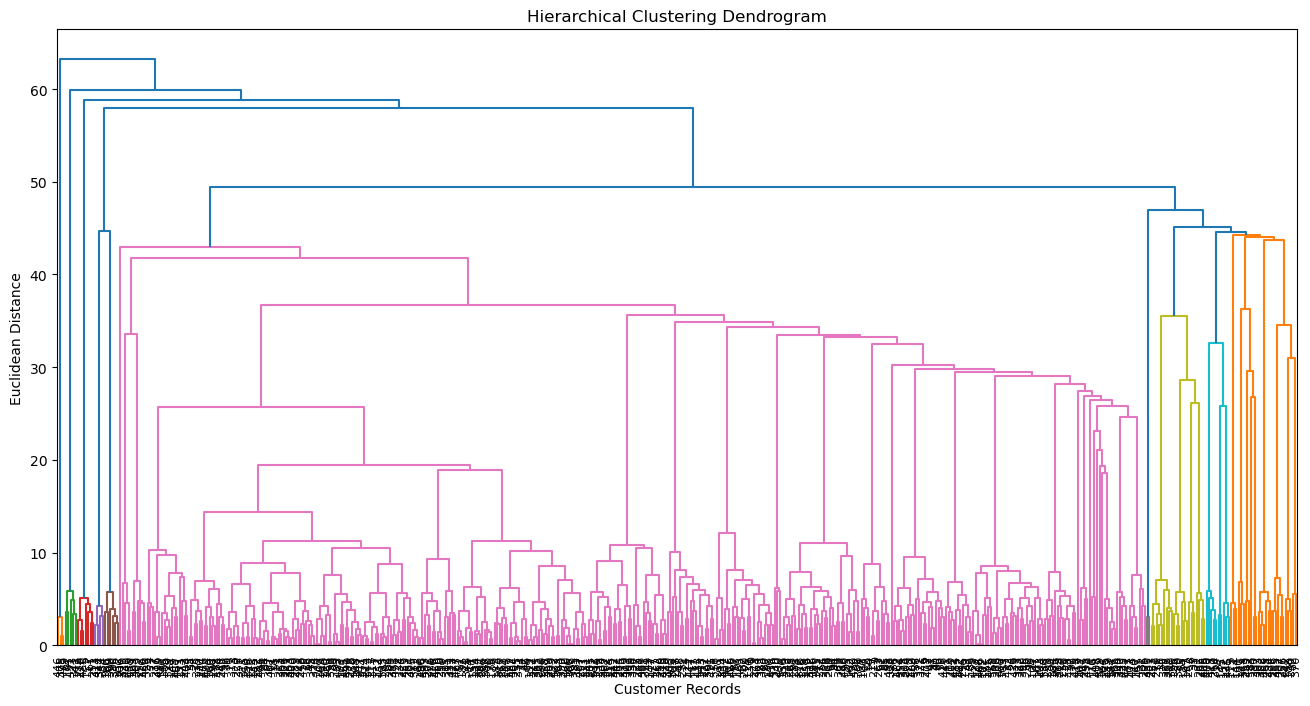

In [65]:
plt.figure(figsize=(16,8))

dendrogram(
    linkage_matrix,
    truncate_mode=None,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customer Records")

plt.ylabel("Euclidean Distance")

plt.show()

### Interpretation

The dendrogram illustrates the hierarchical relationship between customer records. Large vertical distances indicate distinct groups of customers.

The dendrogram supports the presence of approximately **three major customer groups**, which is consistent with the K-Means clustering results obtained using the Elbow Method.

Therefore, the Hierarchical Clustering analysis validates the selection of **three clusters** for customer segmentation.

## Comparison of Clustering Techniques

| Criteria | K-Means | Hierarchical Clustering |
|----------|---------|-------------------------|
| Number of Clusters | Predefined | Determined through dendrogram |
| Speed | Fast | Slower |
| Large Dataset | Suitable | Less efficient |
| Interpretability | Easy | Good visualization |
| Project Result | Selected | Used for validation |

### Conclusion

K-Means clustering was selected as the primary segmentation technique because it performs efficiently on large datasets and produced meaningful customer clusters. Hierarchical Clustering was used to validate the clustering structure and confirmed the presence of three major customer segments.

# Step 11: Save Final Clustered Dataset

In [58]:
df.to_excel("../Dataset/final_clustered_data.xlsx", index=False)

print("Final clustered dataset saved successfully.")

Final clustered dataset saved successfully.


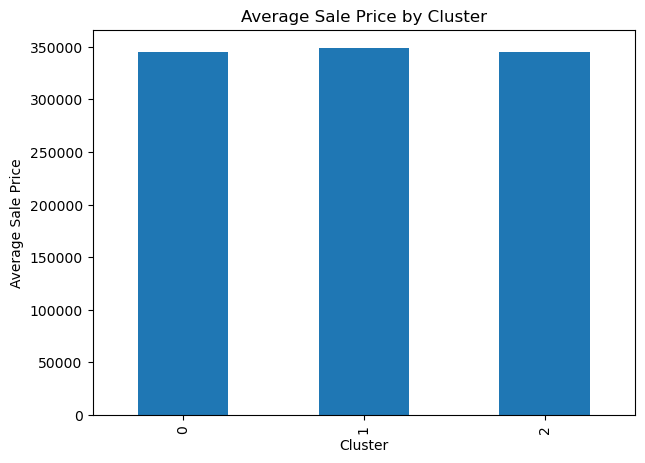

In [59]:
import matplotlib.pyplot as plt

cluster_profile["sale_price"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Sale Price by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Sale Price")

plt.show()

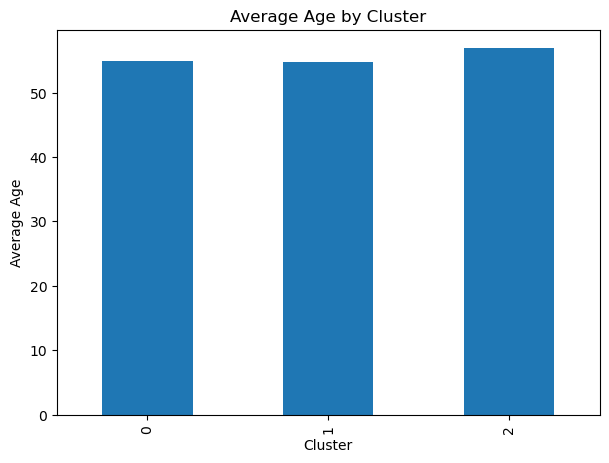

In [60]:
cluster_profile["age"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Age by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Age")

plt.show()

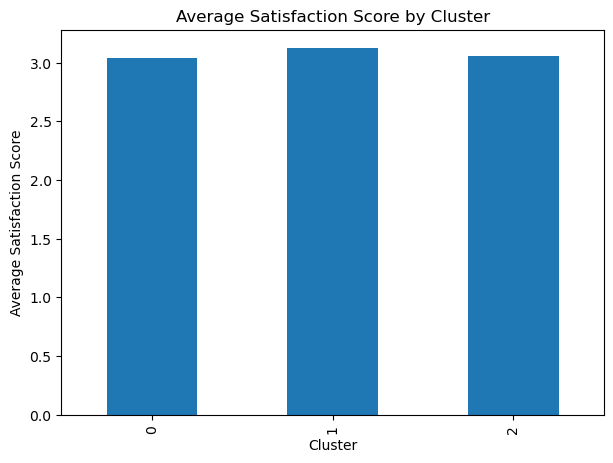

In [61]:
cluster_profile["satisfaction_score"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Satisfaction Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Satisfaction Score")

plt.show()

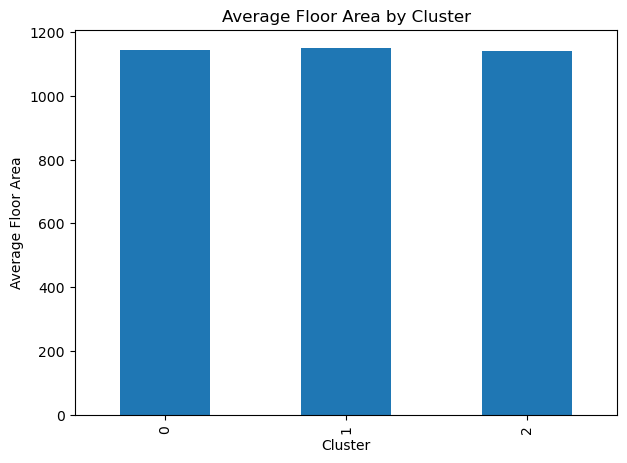

In [62]:
cluster_profile["floor_area_sqft"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Floor Area by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Floor Area")

plt.show()

# Cluster Summary

| Cluster   | Business Name                   | Key Characteristics                                                                      |
| --------- | ------------------------------- | ---------------------------------------------------------------------------------------- |
| Cluster 0 | International Individual Buyers | Mixed countries, mostly individual buyers, balanced residential and investment purchases |
| Cluster 1 | Canadian Home Buyers            | Smallest cluster, Canadian residential buyers, highest satisfaction                      |
| Cluster 2 | Domestic Residential Buyers     | Largest cluster, predominantly USA buyers, mostly residential purchases                  |


# Machine Learning Conclusion

K-Means clustering successfully segmented buyers into three meaningful customer groups.

The Elbow Method indicated that three clusters were appropriate for the dataset, while the Silhouette Score of approximately 0.30 suggested acceptable cluster separation.

Hierarchical Clustering was used as a validation technique and supported the overall grouping structure. The identified customer segments provide valuable insights into buyer demographics, purchasing behaviour, and geographic distribution, enabling more targeted marketing and investment strategies.